In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.isnull().sum()

# Only the income column shows 24 null values so we will take median income and fill that value in the empty space 

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

## 1. Handle Missing Values

In [6]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [7]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## Feature Engineering

### 1) Instead of Year Birth (Date)   we will convert into age column as it is a very good feature for an ecommerce app as it can help analyze the age group of customer buy which projects so such products could be recommended to that age group people

In [8]:
# Age
df["Age"] = 2026 - df["Year_Birth"]

### Now the next thing is Dt_Customer  -> We take Joining Date ka max as reference date as 0 tenure days and subtract others date from this reference date

In [9]:
# Customer Joining Date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst = True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [10]:
# Spending 

df["Total_Spending"]= df["MntWines"] + df["MntFruits"] +df["MntGoldProds"] +df["MntMeatProducts"] +df["MntSweetProducts"] +df["MntFishProducts"]  

In [11]:
# Children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [12]:
# Education

df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic":"Undergraduate","2n Cycle":"Undergraduate",
    "Graduation": "Graduate",
    "PhD":"Postgraduate","Master":"Postgraduate"
})

In [13]:
df["Education"].value_counts()


Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [14]:
# Marital Status

df["Marital_Status"].value_counts()

df["Marital_Status"] = df["Marital_Status"].replace({
    "Married":"Partner","Together":"Partner",
    "Single": "Alone","Divorced":"Alone",
    "Widow":"Alone","Absurd":"Alone","YOLO":"Alone"
})

In [15]:
df["Marital_Status"].value_counts()
df["Living_With"]=df["Marital_Status"]

In [16]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Alone,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Alone,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Partner,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Partner,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Partner,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [17]:
cols = ["ID", "Year_Birth", "Marital_Status","Kidhome", "Teenhome", "Dt_Customer"]
spending_cols =["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns = cols_to_drop)

In [18]:
df_cleaned = df.drop(columns=cols_to_drop)

In [22]:
df.shape

(2240, 27)

In [24]:
df_cleaned.shape
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


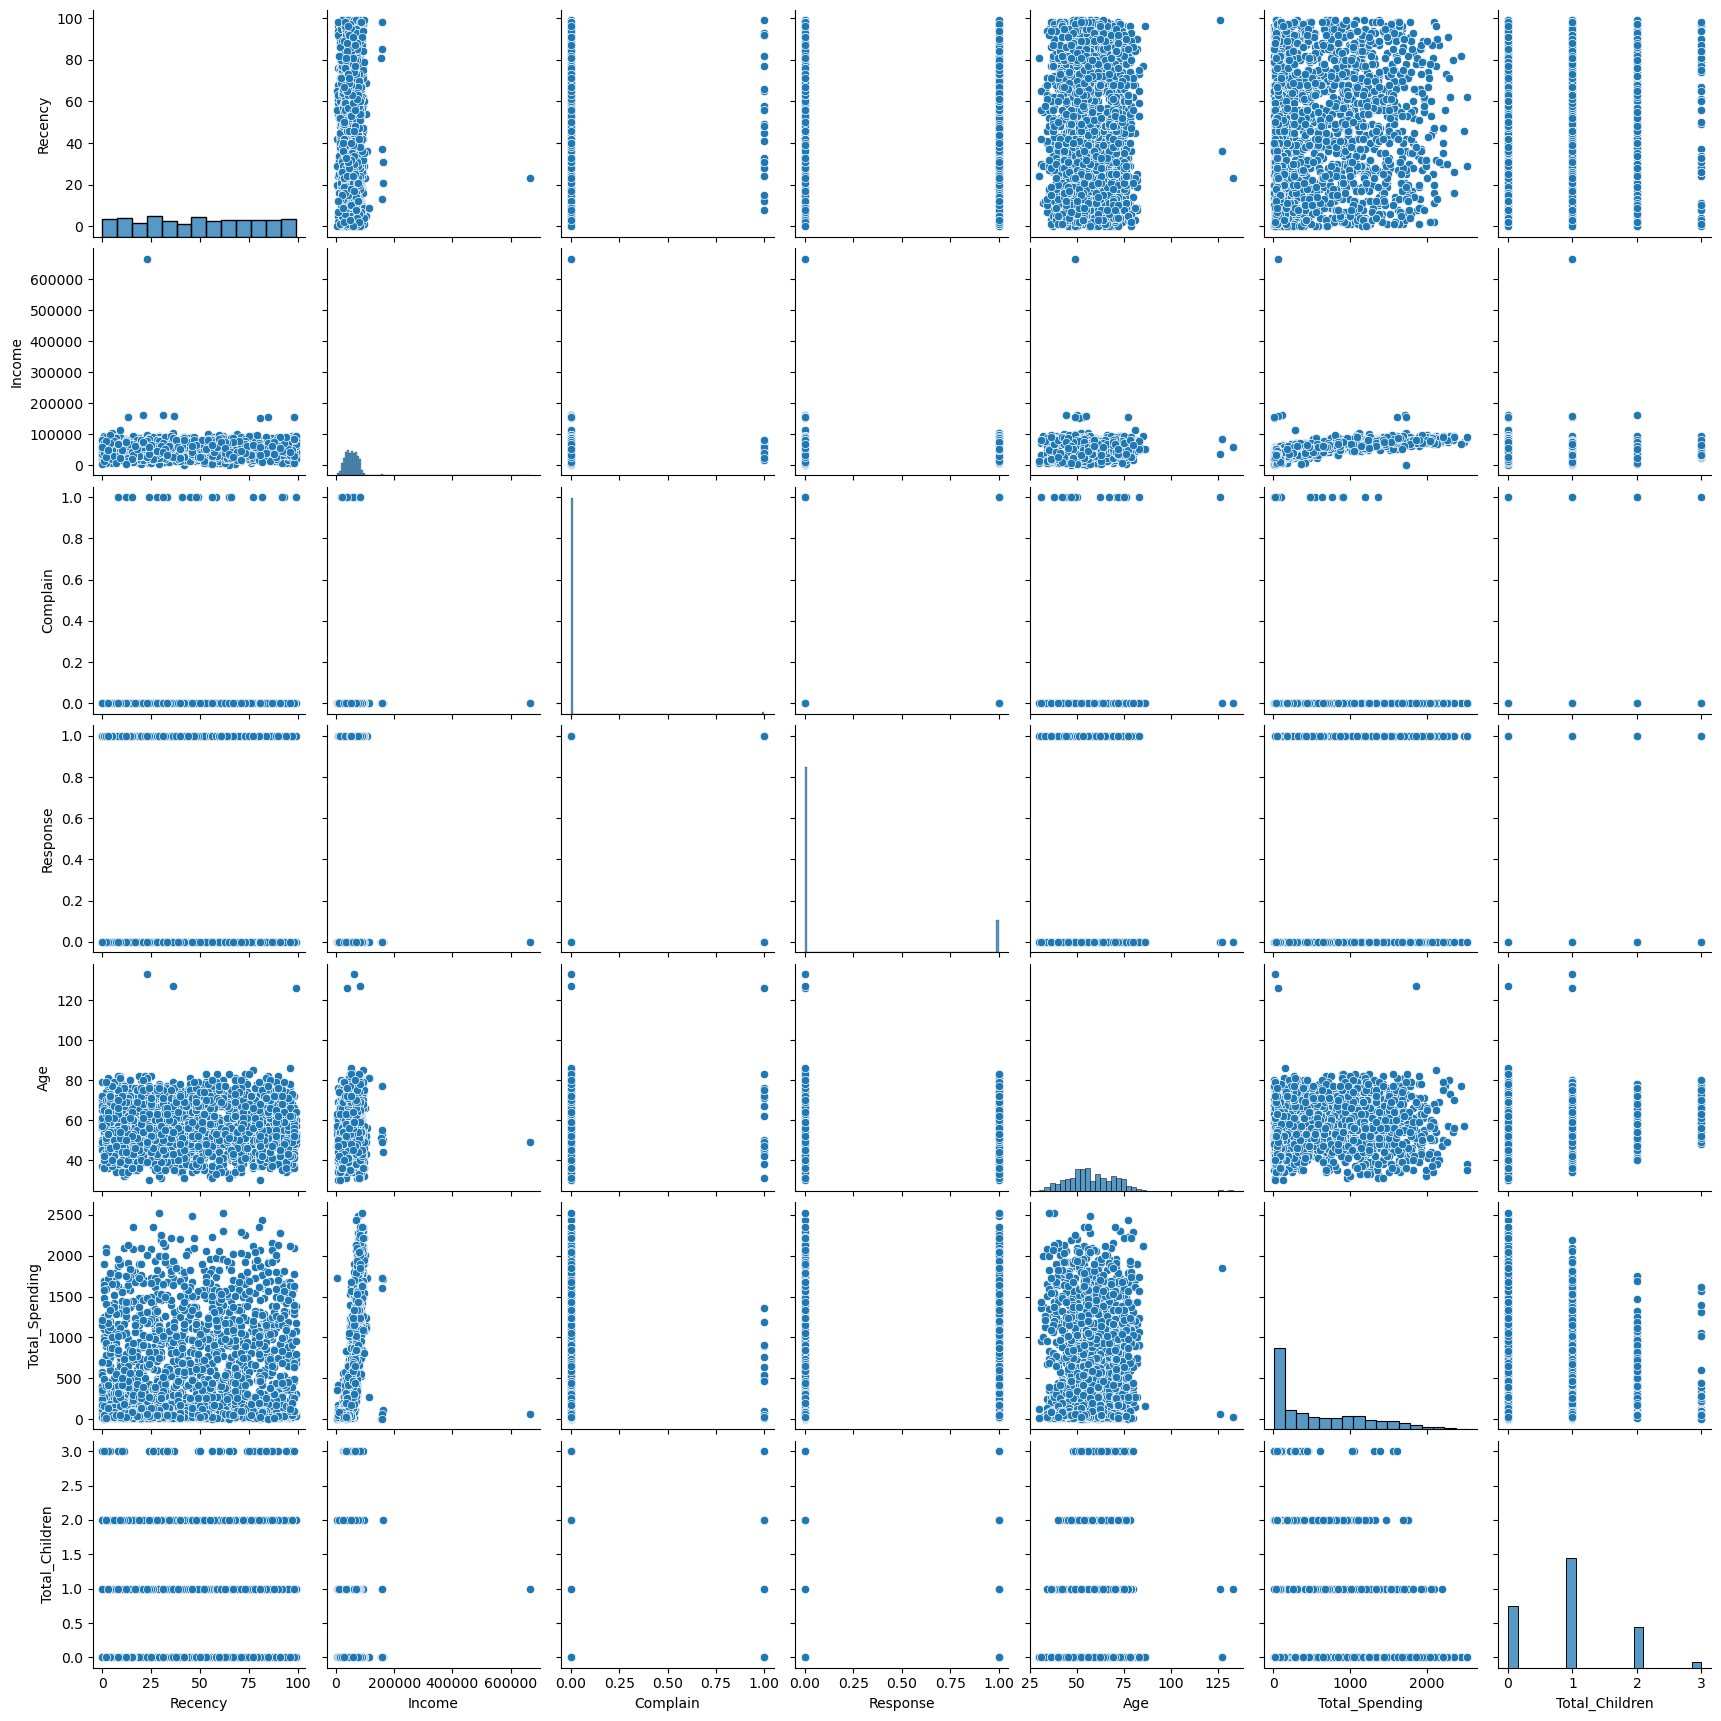

In [27]:
cols = ["Recency","Income","Complain","Response","Age","Total_Spending","Total_Children"]
# Relative plot for some features  -  Pair plot 
sns.pairplot(df_cleaned[cols])

# Handling Outlier

In [32]:
# Looking at the graphs we can viually notice 2 outliers 
# 1 in income and 3 in Age so now we will remove it 

In [33]:
# Remove Outlier

print("data size with outliers", len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Income"]<600000)]
df_cleaned = df_cleaned[(df_cleaned["Age"]<90)]

print("data size without outliers", len(df_cleaned))

data size with outliers 2236
data size without outliers 2236


# Heatmap

In [34]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

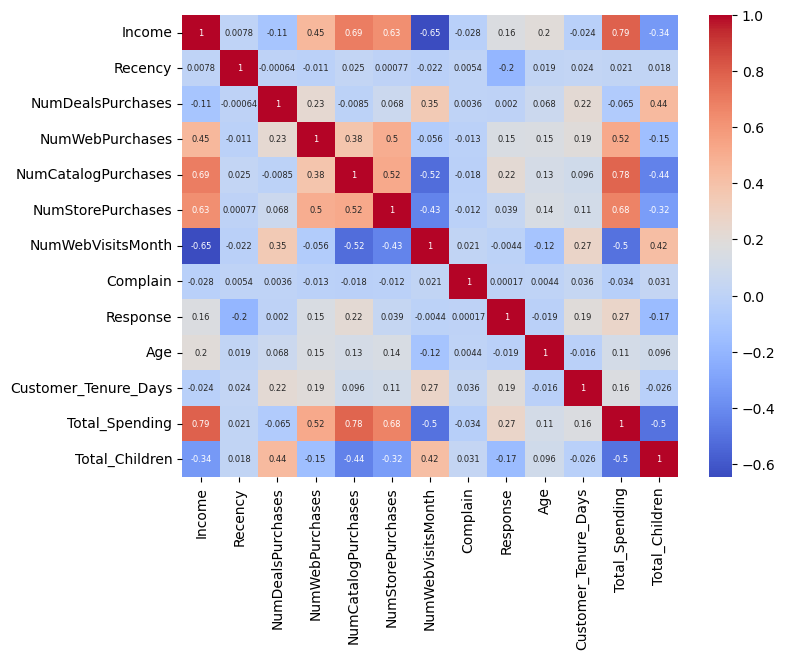

In [35]:
plt.figure(figsize = (8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws = {"size": 6},
    cmap = "coolwarm"
)

In [46]:
# We can understand here ki
## 1) 0.79(red)    ->    Income & Total Spending --- means more income so more Total Spending
## 2) 0.69(red)    ->    Income & Catalog Products --- means more income so more Catalog Products
## 3) 0.63(red)    ->    Income & Store Purchases --- means more income so more store purchases
## 4) -0.65(blue)  ->    Income & Website Visits  --- means more income less website visit
## 5) 0.78(red)    ->    Spending & NumCatelog Purchase --- means More we spend more catelog purchase we make 
## 6) 0.68(red)    ->    Spending & StorePurchases --- means more we spend more from store rather than web


 # Encoding


In [47]:
from sklearn.preprocessing import OneHotEncoder

In [51]:
ohe =OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols]) 

In [53]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns = ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)
enc_df.head()


,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [54]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis =1)

In [55]:
df_encoded.shape

(2236, 18)

In [56]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling

In [57]:
from sklearn.preprocessing import StandardScaler

In [58]:
X = df_encoded

In [60]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Visualize

In [67]:
X_scaled.shape

(2236, 18)

In [68]:
 # 2D
from sklearn.decomposition import PCA

In [69]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

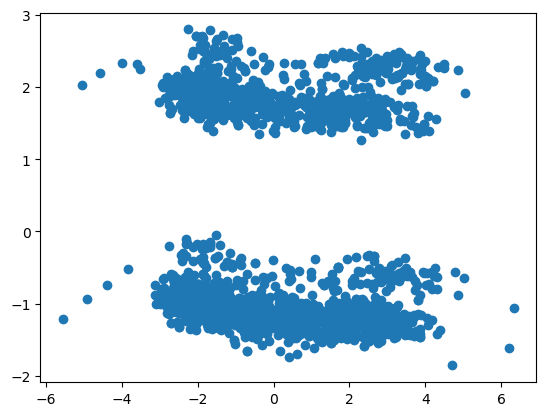

In [70]:
# plot 

plt.scatter(X_pca[:,0], X_pca[:,1])

In [73]:
pca.explained_variance_ratio_

# Majority info is getting lost as 18 feature se 2 features is mot working good so we will incease our dimentions from 2D to 3D

array([0.23163158, 0.11385454])

In [74]:
# 3D 

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

In [75]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

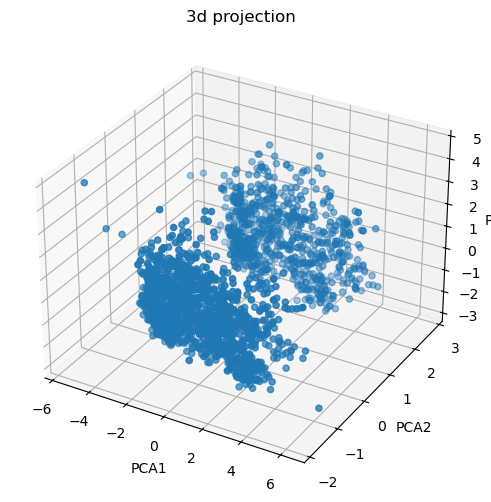

In [81]:
# plot 
fig =plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

In [ ]:
# Still the clusters are not appearing seperate so now we will use 2 main clustering algo and compare their outputs 